In [76]:
# !pip install torch torchvision
# !pip install scikit-learn
# !pip install pandas
# !pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 18.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 17.3 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Vectors

- to visualize vectors, it is components in a coordinate system


## Dot Products

- vector dot products ( scalar product ) provides the angle between two vectors


## Cross Product

- cross product of two vectors provides a new vector that runs perpendicularly to the two vectors
- this is only limited to two vectors in a 3d space to find the third perpendicular vector

In [33]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# 1d vectors
vector_a = np.array([1,2,3,4,5])

# 2d (matrices)
vector_b = np.array([[1,2,3,4,5], [1,2,3,4,5] , [1,2,3,4,5]])
print(vector_a)
# print(vector_b)
#
# print(vector_a.shape)
# print(vector_b.shape)


# 3 dims
vector_c = np.array([
    [[1,2,3,4,5],
     [1,2,3,4,5],
     [1,2,3,4,5]],

    [[1,2,3,4,5],
     [1,2,3,4,5],
     [1,2,3,4,5]]
])

print(vector_c)

# depth , rows, columns
print(vector_c.shape)


[1 2 3 4 5]
[[[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]]
(2, 3, 5)


# Matrices

- 2d arrays

## Matrix Multiplication

- matrix multiplications is only allowed if the inner dimensions are matching , e.g. a 3 by 2 matrix can be multiplied by 2 by 3 , to form a 3 by 3 matrix

## Matrix Transpose

> Transpose of a matrix is a new matrix that is obtained by swapping rows and columns of the given matrix

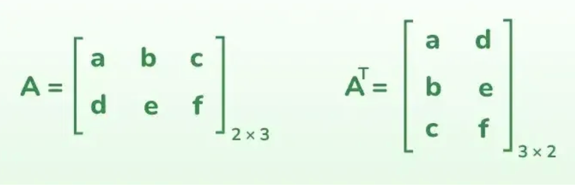



In [41]:
import numpy as np

A = [[1,2] , [2,3]]
B = [[4,5] , [6,7]]

# Matrix multiplication
C = np.dot(A,B)

print(C)

# this will throw an error (inner dont match)
# shape : (2,3) * (2,2)
# A = [[1,2,3] , [1,2,3]]

# this will not throw an error
# shape : (3,2) * (2,2)
A = [[1,2], [1,2] ,[1,2]]
C = np.dot(A,B)
print(C)
# shapes (2,2) and shapes (3,2) are not aligned

A = np.asarray([[1,2,3] , [1,2,3]])
B = np.asarray([[1,2], [1,2] , [1,2]])
# this is fine because A.shape = (2,3) , B.shape = (3,2)
C = np.dot(A,B)
print(C)
print(A.shape)
print(B.shape)

# Matrix transposition
print("A: " + str(A))
print("A (transposed): " + str(A.transpose()))





[[16 19]
 [26 31]]
[[16 19]
 [16 19]
 [16 19]]
[[ 6 12]
 [ 6 12]]
(2, 3)
(3, 2)
A: [[1 2 3]
 [1 2 3]]
A (transposed): [[1 1]
 [2 2]
 [3 3]]


# Tensors / Pytorch
> tensors are multi-dimensional array of numbers , generalizes scalars, vectors, matrices to higher dimensions

- rank 0 => scalar
- rank 1 => vector
- rank 2 => matrix
- rank n => n-dimensional array

Pytorch allows easy creation of tensors with `torch.empty(a,b,c...)`
you define the number of dimensions, and the length of each dimension


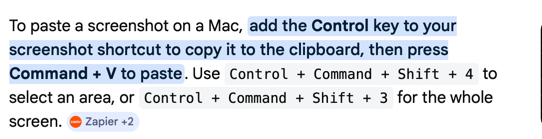

In [28]:
import torch
import math

# 3 x 4 * 5 (3 dimensions)
x = torch.empty(3,4,5)
print(type(x))
# print(x)

# 3 x 4 x 5 x 6 (4 dimensions)
y = torch.empty(3,4,5,6)
print(type(y))
print(y)


<class 'torch.Tensor'>
<class 'torch.Tensor'>
tensor([[[[0.0000e+00, 0.0000e+00, 1.7236e-43, 0.0000e+00, 1.1602e-34,
           1.4013e-45],
          [3.5841e-27, 1.4013e-45, 0.0000e+00, 0.0000e+00,        nan,
                  nan],
          [       nan,        nan, 0.0000e+00, 0.0000e+00, 1.4013e-45,
           0.0000e+00],
          [0.0000e+00, 0.0000e+00, 1.2612e-44, 0.0000e+00, 2.2028e-27,
           1.4013e-45],
          [3.5857e-27, 1.4013e-45,        nan,        nan, 0.0000e+00,
           0.0000e+00]],

         [[       nan,        nan, 0.0000e+00, 0.0000e+00, 1.4013e-45,
           0.0000e+00],
          [1.0089e-43, 0.0000e+00, 1.5414e-44, 0.0000e+00, 2.2028e-27,
           1.4013e-45],
          [3.5857e-27, 1.4013e-45, 1.4013e-45, 0.0000e+00, 3.9236e-44,
           0.0000e+00],
          [       nan,        nan, 0.0000e+00, 0.0000e+00, 1.4013e-45,
           0.0000e+00],
          [2.0179e-43, 0.0000e+00, 1.5414e-44, 0.0000e+00, 2.2028e-27,
           1.4013e-45]],



# Gradient Descent

- in gradient descend , we aim to find the local extrema of a function.
- in many models, loss surface has a local minima that may not be a global minima , and saddle points which trap and slow optimizations
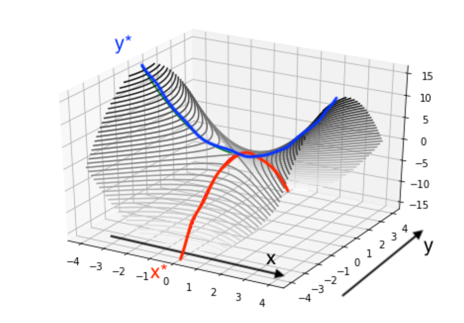
- in linear regression however, the loss function is convex
    - meaning with linear regression, we can always get an optimum solution.
    - by using gradient descend, we can find the optimal slope and y-intercept by minimizing the MSE (Mean Squared Error)

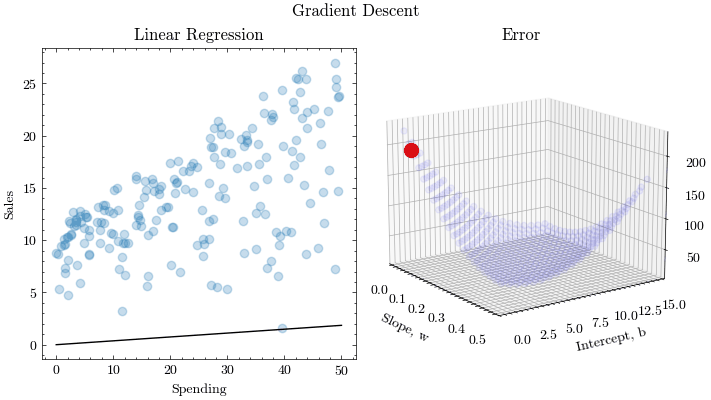


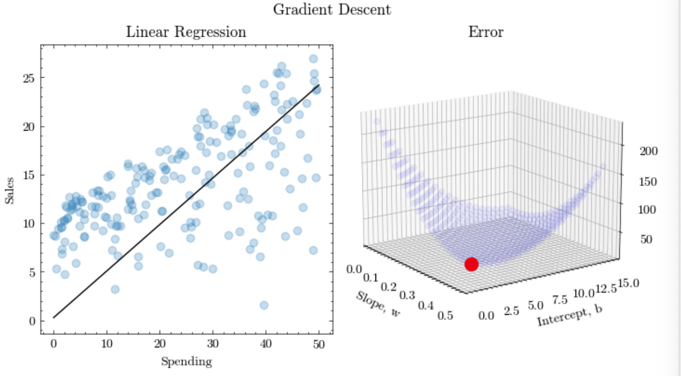

# TorchVision

> Toolkit for computer vision. It provides popular datasets, model architectures, and common image transformations for computer vision

- purpose is to standardize tasks such as loading CIFAR-10 or imageNet datasets, applying image augmentations, building convolutional neural networks and others

# Vectorization

> act of transforming human language into a format that machines can comprehend and process (numerical representations or vectors )

- this provides semantic understanding , as vector can capture meaning of words and relationships
- this provides the avenue to do semantic search through focusing on meaning

## Techniques

### One-hot Encoding

- each word is represented by a vector with a high bit

e.g. feature is Color
| Red    | Blue | Green |
| -------- | ------- | --------- |
| 1        | 0       | 0         |
| 0        | 1       | 0         |
| 0        | 0       | 1         |

#### Advantages
- simple and easy to understand
- preserves independence of categories
    - each category is treated as independent. this is important when dealing with nominal data ( data with no order ).

#### Disadvantages
- curse of dimensionality
    - every new category gets its own binary column, with high-cardinality features, this approach creates a sparse dataset with many zeros
    - too many columns can slow down model , increase memory usage , and reduce performance


In [55]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    "Colors" : ["Red" , "Yellow" , "Blue" , "Green", "Black"]
}

df = pd.DataFrame(data)

encoder = OneHotEncoder(sparse_output=False)

ohe = encoder.fit_transform(df)

ohe_df = pd.DataFrame(ohe, columns=encoder.get_feature_names_out())

ohe_df


,Colors_Black,Colors_Blue,Colors_Green,Colors_Red,Colors_Yellow
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0


# BOW/TF-IDF

- text is convert to a vector , by counting occurrences of each word in a document
- TF-IDF extends this by weighing frequency of a word by their importance across documents
- TF (t,d) = number of terms t appears in document d/ total number of terms in document d
- IDF (t) = log(total num of documents / number of documents containing term t)

## Advantages
- simple and efficient
- importance weighing

## Disadvantages
- high dimension, sparse vectors, increases memory and computation

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus =  [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?"
]

vectorizer = TfidfVectorizer()

x = vectorizer.fit_transform(corpus)

x



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (4, 9)>

# Word Embeddings

- dense vector representations of words in a continuous vector space where semantically similar words are located close to each other
- embeddings captures
    - the context of words
    - its syntactic role
    - semantic relationships with other words
- each number within a embedding represents a coordinate within a high dimensional space
- (king - man + woman) approximates to queen

# Linear Regression Model

- part of supervised learning
- learns from the labelled datasets and maps the data points with most optimized linear functions which can be used for prediction on new datasets

## Assumptions

1. relationship is linear

- 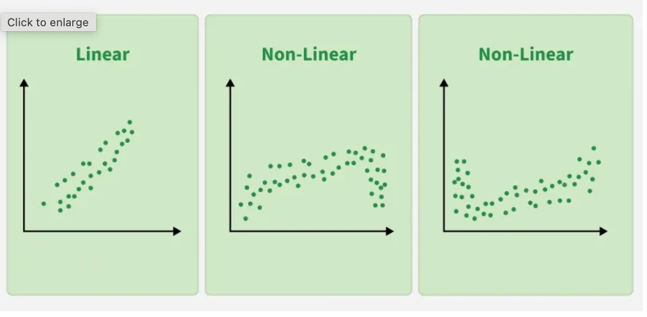

2. errors in predictions are independent ( do not affect each other )
3. constant variance (Homoscedasticity) , errors have equal spread across all values of the input
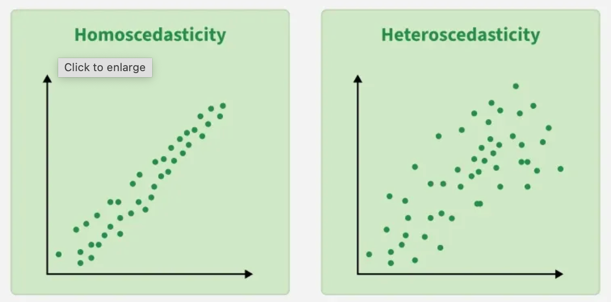
4. normality of errors , errors should follow a bell-shaped distribution

## Types of Linear Regression

1. simple linear regression
   1. y = mx + c
2. multiple linear regression
   1. y = c + mx + m2x2 + m3x3 + ... + mnxn

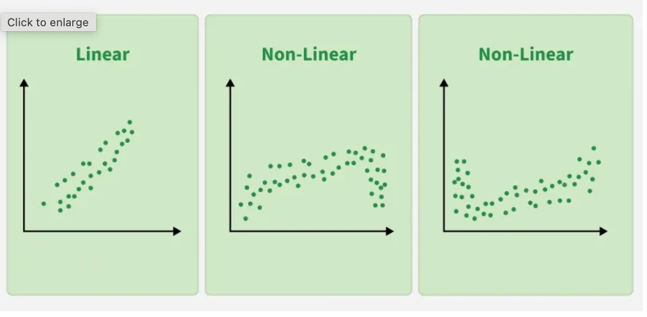

# Weights & Biases
- components in many machine learning models (linear regression , neural nets)
- complex patterns are learned as the model iteratively updates its weights and biases to minimize error.


## Weights

- numerical values assigned that determine how much influence each input has on the final output

## Biases

- additional parameters that adjust the output, used to shift activation function to better fit data


# Parameters & Hyperparameters


- model parameter is a variable of the selected model which is used to represent the underlying relationships in the data

- hyperparameter , is a variable set before the training process begins, (learning rate, regularization strength, number of hidden layers in a neural network)

In [72]:
import numpy as np
# create dummy data for training
x_values = [i for i in range(11)]
x_train = np.array(x_values, dtype=np.float32)
x_train = x_train.reshape(-1, 1)

# introduce some noise to simulate randomness
noise = np.random.randint(-3,4, size = x_train.shape).astype(np.float32)




y_train = 2 * x_train + 1 + noise


# Linear Regression: generating predictions


1. First we need to define a `LinearRegression` class that inherits from the `torch.nn.module`
2. when initializing, we create a fully connected dense layer that applies a linear transformation with `torch.nn.Linear`
3. we also override the forward function `forward()` to define how data flows through the model

In [ ]:
import torch
from torch.autograd import Variable

# Inherit module to create a linear regression class
class LinearRegression(torch.nn.Module) :
    def __init__(self, inputSize, outputSize):

        super(LinearRegression, self).__init__()

        # creates a fully connected layer that applies linear transformation to incoming data
        self.linear = torch.nn.Linear(inputSize, outputSize)

    # defines how data flow through the model
    # for linear regression, we just need input -> linear layer -> output prediction
    def forward(self, x):
        out = self.linear(x)
        return out


# Defining Hyperparameters

1. inputDim: 1, because we only expect one feature or 1d data
2. outputDim: 1 as model predicts only 1 value per observation
3. learningRate: defines step size , too small may cause training to be slow , too large may overshoot and not converge
4. epochs: defines how many times the model goes through the dataset, the higher, the better the learning but too many leads to overfitting

In [74]:
inputDim = 1
outputDim = 1
learningRate = 0.01
epochs = 100

# Instantiating and running the model

at every step, we need to
1. get y_pred
2. calculate MSE with y_pred & y_train
3. compute gradient descent with backpropagation
4. update weights and bias

In [73]:

model = LinearRegression(inputDim, outputDim)

# this measures error between y_train and y_pred
criterion = torch.nn.MSELoss()

'''
SGD (Stochastic Gradient Descent) : updates model weights

model.parameters() : tells model which weights/bias to update (1 weight, 1 bias)
'''
optimizer = torch.optim.SGD(model.parameters(), lr = learningRate)

for epoch in range(epochs) :
    inputs = Variable(torch.from_numpy(x_train))
    labels = Variable(torch.from_numpy(y_train))

    # set gradients to zero before backpropagation, to prevent gradient accumulation
    optimizer.zero_grad()

    outputs = model(inputs)

    # find MSE with y_pred and y_train
    loss = criterion(outputs, labels)

    # computes gradients
    loss.backward()

    # update weights & bias
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))


epoch 0, loss 109.40003204345703
epoch 1, loss 12.442163467407227
epoch 2, loss 4.530593395233154
epoch 3, loss 3.8822805881500244
epoch 4, loss 3.8264434337615967
epoch 5, loss 3.8189642429351807
epoch 6, loss 3.8154637813568115
epoch 7, loss 3.812317132949829
epoch 8, loss 3.8092339038848877
epoch 9, loss 3.8061866760253906
epoch 10, loss 3.8031747341156006
epoch 11, loss 3.80019474029541
epoch 12, loss 3.7972471714019775
epoch 13, loss 3.794335126876831
epoch 14, loss 3.7914540767669678
epoch 15, loss 3.7886056900024414
epoch 16, loss 3.7857887744903564
epoch 17, loss 3.783003330230713
epoch 18, loss 3.780249834060669
epoch 19, loss 3.777526617050171
epoch 20, loss 3.774832010269165
epoch 21, loss 3.772169589996338
epoch 22, loss 3.7695372104644775
epoch 23, loss 3.766932725906372
epoch 24, loss 3.76435923576355
epoch 25, loss 3.7618117332458496
epoch 26, loss 3.7592954635620117
epoch 27, loss 3.756805419921875
epoch 28, loss 3.754343271255493
epoch 29, loss 3.751908779144287
epoch 

# Plotting visualization

1. prediction line should cut across close to centre of the training observations whilst minimizing MSE

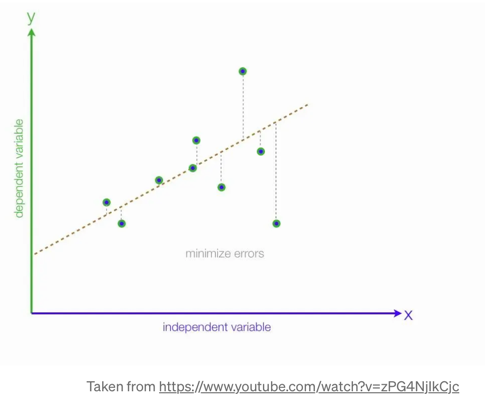


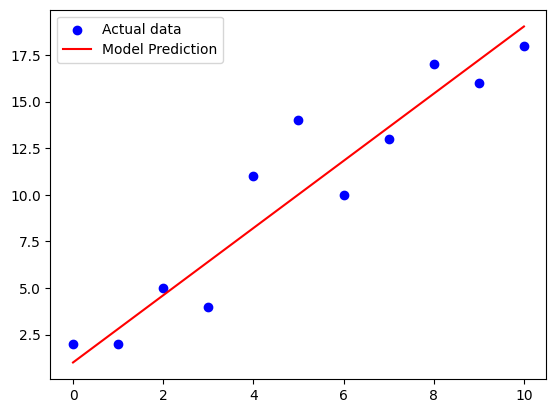

In [81]:
import matplotlib.pyplot as plt
y_pred = model(Variable(torch.from_numpy(x_train))).data.numpy()

plt.scatter(x_train, y_train, color='blue' , label='Actual data')

plt.plot(x_train,y_pred, color='red', label='Model Prediction')

plt.legend()
plt.show()

# Making Predictions

In [83]:
model.eval()

x_test_values = [i for i in range(11,16)]
x_test = np.array(x_test_values, dtype=np.float32)
x_test = x_test.reshape(-1, 1)

# disable gradient tracking, to reduce memory usage
with torch.no_grad() :
    inputs = torch.from_numpy(x_test)

    outputs = model(inputs)

outputs

tensor([[20.8314],
        [22.6335],
        [24.4357],
        [26.2378],
        [28.0399]])

# Cost Function & Loss Function


## Cost Function
- used to refer to an average of the loss functions over an entire training data
- helps us to reach the optimal solution
- outputs a higher number if predictions differ a lot from actual values
- cost function can act as a indicator of how the model has improved as we tune the model

### Types

### Regression cost functions

1. Mean Squared Error (MSE)
    1. square of the difference between actual and predicted for each observation
    2. penalize even small deviations

2. Mean Absolute Error (MAE)
    1. average of the sum of absolute differences between predictions and actual observations
    2. will give better results when dataset has noise or outliers

### Classification problems

Cross Entropy
    1. calculates how far the predicted probability distribution is from the actual one.
    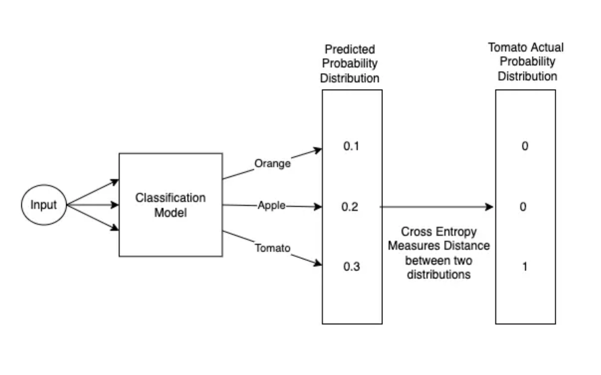
Multi-class Classification cost functions
    1. used in classification problems where there are multiple classes and input data belongs to only one class
    2.

## Lost Function
- used when we refer to the error for a single training example.

### Sparse Categorical Crossentropy



### Categorical Crossentropy
- measures how well the predicted probabilities of each class align with the actual target labels.

- evaluates a classification model's performance by comparing the model's predicted probabilities for each class with the actual class labels

- requires the target labels to be in one-hot-encoded format

## Sparse Categorical Crossentropy
- designed for targets labels that are not one-hot-encoded.

- labels are represented as integers corresponding to the class indices

- for each input sample, the model predicts a probability distribution over all classes, often using a softmax activation in the final layer


# Mean Squared Error

- lower MSE indicates that the model's predictions are closer to actual values, signifying better accuracy
- higher MSE indicates model's predictions deviates further from the true value
- this way of calculating error penalizing large errors more heavily than small errors, making it sensitive to outliers

In [ ]:
#

# Back Propagation

- plays a critical role in how neural networks improve over time.

- allows for

    1. Efficient Weight Updates : computes the gradient of the loss function with respect to each weight , making it possible to update weights efficiently
    2. the learning process to become automated and the model can adjust itself to optimize its performance

## Forward Pass

> this is where input data is fed into the input layer . inputs combined with their respective weights are passed down to hidden layers.

- e.g. in a network with two hidden layers (h1 and h2) the output from h1 serves as the input to h2.
- At the end, a bias is added to the weighted inputs , before an activation function is applied ( ReLU, softmax etc.)

## Backward Pass / Gradient Descend

> Difference between the predicted and actual output (error calculation)  is propagated through the network , to adjust the weights and biases

- weights and biases are adjusted using gradients computed with the chain rule
- gradients indicate how much (and in which direction for weights) each weight and bias needs to be adjusted to minimize the error in the next iteration
- it does this through partial derivatives, if the value is high, it would mean that a small change in that weight will cause a large change in the loss

## Gradient Descent

- the role of the gradient descent (in neural nets) is to update the weights using gradients from backpropagation
- the aim is to reduce prediction error across all layers
- enables deep learning with nonlinear boundaries

# Epoch

> refers to one complete pass through the entire training dataset where every data sample is passed through the model

- Within an epoch , its parameters are also updated based on the calculated error
- Training process usually requires many multiple epochs
- in deep learning, datasets are divided into smaller subsets known as batches
- if there are n batches, one epoch , would involve processing n batches.
- Increasing epoch can improve performance and accuracy, but overusing epochs leads to overfitting and increased computational cost



# Learning Rate

> learning rate controls how much model's weights are adjusted during training

- high learning rate may overshoot the optimal weight, whilst a low learning rate can make the training slow

## Learning Rate Decay

- technique where the learning rate gradually decreases during training. This helps the model make large adjustments at the start, and smaller adjustments near the optimal solution






# Optimizer

> optimizer is an algorithm used to adjust model parameters (usually weights and biases) during training to minimize loss function

## Types

- Stochastic Gradient Descent (SGD)
    - updates parameters by subtracting the gradient of the loss scaled by learning rate
    - too inefficient as learning rate is constant

- Adagrad
    - adapts learning rate for each parameter, performing larger updates for infrequent parameters.
    - Recommended for sparse data, used in models like Word2Vec and text classifiers
    - reduces learning rate very aggressively
- Root Mean Square Propagation (RMSprop)
    - Variant of the gradient descent algorithm by adapting learning rate considering the magnitude f recent gradients of those parameters
    - maintains moving average of squared gradients, normalizing them to handle non-stationary objectives.
    - Recommended for RNNs like InceptionV3, LSTM, GRUs